In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter,defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Dataset,Subset,DataLoader,random_split
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
import itertools
import regex as re
import pickle

In [2]:
from google.colab import drive
import os,sys
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
class RoPE(nn.Module):
  def __init__(self,theta,emb_dim,context_len):
    super().__init__()
    assert emb_dim%2==0
    half=emb_dim//2

    half_ids=torch.arange(0,half)
    inv_freq=1.0/(theta**((2.0*half_ids)/emb_dim))

    pos=torch.arange(context_len)
    angles=pos[:,None]*inv_freq[None,:]

    self.register_buffer("cos_cache",torch.cos(angles))
    self.register_buffer("sin_cache",torch.sin(angles))

  def forward(self,x):
    b,h,c,d=x.shape

    org_dtype=x.dtype
    x=x.float()

    cos=self.cos_cache[:c]
    sin=self.sin_cache[:c]

    x_even=x[...,0::2]
    x_odd=x[...,1::2]

    x_rot_even=x_even*cos-x_odd*sin
    x_rot_odd=x_even*sin+x_odd*cos

    x_rot=torch.stack([x_rot_even,x_rot_odd],dim=-1)
    x_rot=x_rot.reshape(b,h,c,d)

    return x_rot.type(org_dtype)

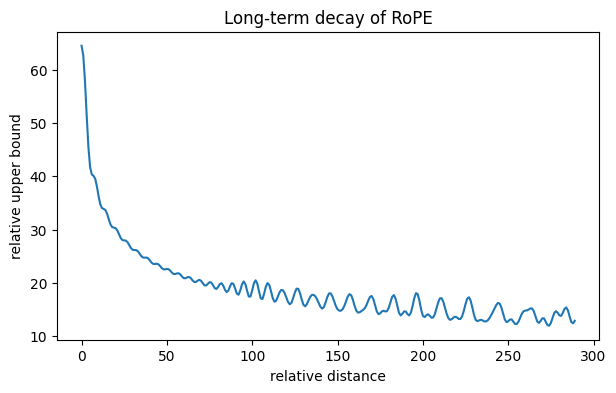

In [15]:
d = 256
max_dist = 17*17
rope = RoPE(theta=10000, emb_dim=d, context_len=max_dist + 1)

# e^{i r θ_i} = cos(rθ_i) + i sin(rθ_i), shape (R, d/2)
phase = torch.complex(rope.cos_cache, rope.sin_cache)

S = torch.cumsum(phase, dim=1)
bound = S.abs().mean(dim=1)

plt.figure(figsize=(7, 4))
plt.plot(range(max_dist + 1), bound.numpy())
plt.xlabel("relative distance")
plt.ylabel("relative upper bound")
plt.title("Long-term decay of RoPE")
plt.show()

# Axial 2d RoPE